Epoch 1 bitti.
Epoch 2 bitti.
Epoch 3 bitti.
Epoch 4 bitti.
Epoch 5 bitti.


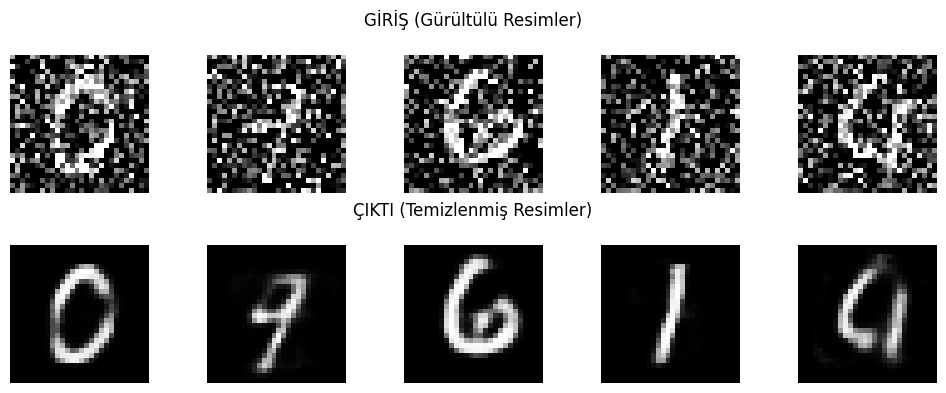

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

# 1. AYARLAR VE VERİ (Sadece Denoising Odağı)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
transform = transforms.Compose([transforms.ToTensor()])
train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)

# 2. MODEL (Basit ve Güçlü)
class DenoisingAutoencoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(nn.Linear(784, 256), nn.ReLU(), nn.Linear(256, 64))
        self.decoder = nn.Sequential(nn.Linear(64, 256), nn.ReLU(), nn.Linear(256, 784), nn.Sigmoid())
    def forward(self, x):
        x = x.view(-1, 784)
        return self.decoder(self.encoder(x)).view(-1, 1, 28, 28)

model = DenoisingAutoencoder().to(device)
optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.MSELoss()

# 3. EĞİTİM (Gürültüyle Mücadele)
epochs = 5 
for epoch in range(epochs):
    for data in train_loader:
        img, _ = data
        img = img.to(device)
        
        # Gürültü Ekleme
        noisy_img = torch.clamp(img + 0.5 * torch.randn_like(img), 0., 1.)
        
        output = model(noisy_img)
        loss = criterion(output, img) # Çıktıyı "temiz" haliyle kıyasla
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    print(f"Epoch {epoch+1} bitti.")

# 4. GÖRSELLEŞTİRME: SADECE KİRLİ VE TEMİZ HALİ
model.eval()
with torch.no_grad():
    test_img, _ = next(iter(train_loader))
    test_img = test_img.to(device)
    noisy_test = torch.clamp(test_img + 0.5 * torch.randn_like(test_img), 0., 1.)
    reconstructed = model(noisy_test)

plt.figure(figsize=(10, 4))
for i in range(5):
    # Üst Satır: Kirli Giriş
    plt.subplot(2, 5, i + 1)
    plt.imshow(noisy_test[i].cpu().squeeze(), cmap='gray')
    if i == 2: plt.title("GİRİŞ (Gürültülü Resimler)\n")
    plt.axis('off')

    # Alt Satır: Temizlenmiş Çıktı
    plt.subplot(2, 5, i + 6)
    plt.imshow(reconstructed[i].cpu().squeeze(), cmap='gray')
    if i == 2: plt.title("ÇIKTI (Temizlenmiş Resimler)\n")
    plt.axis('off')

plt.tight_layout()
plt.show()